In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pygt3x.reader import FileReader
from tqdm.notebook import tqdm
from sklearn.decomposition import PCA
from scipy.signal import butter, filtfilt
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

In [49]:
tsheet = pd.read_excel("/mnt/sdb/arafat/6mw/TimeSheet6MW.xlsx")
tsheet

,Sub,Name,Date_Base,SixMW_Time_Base,SixMWDistanceBase,TwoMW_TimeStart_Base,Date_V1,SixMW_TimeStart_V1,SixMWDistanceV1,TwoMW_TimeStart_V1,...,SixMWDistanceV2,TwoMW_TimeStart_V2,Date_V3,SixMW_TimeStart_V3,SixMWDistanceV3,TwoMW_TimeStart_V3,Date_V4,SixMW_TimeStart_V4,SixMWDistanceV4,TwoMW_TimeStart_V4
0,M-01,DB,2016-06-14,16:23:00,2053.0,16:44:00,2023-06-12,NaN,2175.0,NaN,...,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaN,NaN,NaN
1,M-02,JT,2016-06-20,11:23:00,1941.0,10:53:00,2022-06-16,14:09:00,2269.0,14:55:00,...,2509.0,14:29:00,NaT,NaN,NaN,NaN,NaT,NaN,NaN,NaN
2,M-04,CR,2016-07-01,12:37:00,2301.0,12:09:00,2025-02-24,13:21:00,2612.0,13:46:00,...,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaN,NaN,NaN
3,M-05,TB,2016-07-05,15:15:00,2024.0,15:36:00,NaT,NaN,NaN,NaN,...,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaN,NaN,NaN
4,M-06,CL,2016-07-07,13:58:00,1872.0,14:20:00,2019-09-19,16:14:00,1289.0,16:47:00,...,1578.5,14:29:00,2023-08-18,16:21:00,1616.0,16:28:00,2025-02-03,12:47:00,1616.0,13:08:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142,C-81,NaN,NaT,NaN,1316.0,NaN,NaT,NaN,NaN,NaN,...,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaN,NaN,NaN
143,C-82,NaN,NaT,NaN,2067.0,NaN,NaT,NaN,NaN,NaN,...,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaN,NaN,NaN
144,C-83,NaN,NaT,NaN,1927.0,NaN,NaT,NaN,NaN,NaN,...,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaN,NaN,NaN
145,C-84,NaN,NaT,NaN,1570.0,NaN,NaT,NaN,NaN,NaN,...,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaN,NaN,NaN


In [52]:
# --- imports ---
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.signal import butter, filtfilt
from sklearn.decomposition import PCA
# Ensure you import your GT3X reader; e.g.:
# from your_gt3x_library import FileReader  # <-- replace with your actual import

# --- utilities ---

def resample(df: pd.DataFrame, target_len: int = 10800) -> pd.DataFrame:
    """
    Uniformly resample each column of df to target_len using linear interpolation.
    Assumes original samples are uniformly spaced.
    """
    arr = df.values if isinstance(df, pd.DataFrame) else np.asarray(df)
    n, d = arr.shape
    newt = np.linspace(0, n - 1, target_len)
    oldt = np.arange(n)
    out = np.empty((target_len, d), dtype=float)
    for j in range(d):
        out[:, j] = np.interp(newt, oldt, arr[:, j])
    return pd.DataFrame(out, columns=getattr(df, "columns", [f"col{j}" for j in range(d)]))

def lowpass(acc, cutoff_hz, fs, order=4):
    """
    Column-wise zero-phase Butterworth low-pass with guards for short and near-constant signals.
    """
    nyq = 0.5 * fs
    wn = cutoff_hz / nyq
    b, a = butter(order, wn, btype='low', analog=False)

    if isinstance(acc, pd.DataFrame):
        acc = acc.values
    acc = np.asarray(acc)

    # Guard ultra-short segments for filtfilt (requires padding)
    if acc.shape[0] < 3 * max(len(b), len(a)):
        return acc.copy()

    # Guard near-constant columns to avoid numerical artifacts at edges
    filt = np.empty_like(acc, dtype=float)
    for i in range(acc.shape[1]):
        col = acc[:, i]
        if np.nanstd(col) < 1e-8:
            filt[:, i] = col
        else:
            filt[:, i] = filtfilt(b, a, col, method="pad")
    return filt

def estimate_gravity(acc, fs, cutoff_hz=0.7):
    """
    Estimate gravity direction via very-low-pass filtering and mean direction.
    """
    g = lowpass(acc, cutoff_hz=cutoff_hz, fs=fs, order=4)
    g_mean = np.mean(g, axis=0)
    g_dir = g_mean / (np.linalg.norm(g_mean) + 1e-12)
    return g_dir

def _pick_xyz(df):
    """
    Select accelerometer axes from a gt3x pandas.DataFrame.
    Prefers ['X','Y','Z']; falls back to first three numeric columns.
    """
    for cand in (["X", "Y", "Z"], ["Axis1", "Axis2", "Axis3"], ["x", "y", "z"]):
        if all(c in df.columns for c in cand):
            return df[cand].copy()
    numcols = df.select_dtypes(include=[np.number]).columns.tolist()
    if len(numcols) < 3:
        raise ValueError("Could not find three numeric accelerometer columns.")
    return df[numcols[:3]].copy()

def _resample_mask(mask_bool, target_len):
    """
    Resample a boolean mask to target_len by interpolating {0,1} and thresholding at 0.5.
    """
    mask_bool = np.asarray(mask_bool, dtype=bool)
    oldt = np.arange(mask_bool.size, dtype=float)
    newt = np.linspace(0.0, mask_bool.size - 1.0, target_len)
    vals = np.interp(newt, oldt, mask_bool.astype(float))
    return vals >= 0.5

def butterworth_lowpass_filter(anatomical_df, cutoff=5, fs=30, order=4):
    """
    Low-pass anatomical signals; default 5 Hz is typical for sway at 30 Hz sampling.
    """
    acc = anatomical_df.values if isinstance(anatomical_df, pd.DataFrame) else np.asarray(anatomical_df)
    filtered = lowpass(acc, cutoff_hz=cutoff, fs=fs, order=order)
    return pd.DataFrame(filtered, columns=["ML", "AP", "SI"])

# --- core projection ---

def project_straight_sway(acc_data, sampling_rate=30, window_sec=3,
                          heading_var_thresh=np.deg2rad(12)):
    """
    Project raw device-frame acceleration to anatomical axes (ML, AP, SI) for the full bout.
    Also returns a boolean mask of straight-walking samples based on heading-change thresholding.

    Returns
    -------
    anatomical_df: pd.DataFrame with columns ["ML","AP","SI"] for the entire bout
    si: np.ndarray unit vector (vertical)
    ap: np.ndarray unit vector (forward/anterior)
    straight_mask: np.ndarray bool mask, same length as the bout
    """
    acc = acc_data.values if isinstance(acc_data, pd.DataFrame) else np.asarray(acc_data)
    fs = sampling_rate
    n = acc.shape[0]

    gravity_dir = estimate_gravity(acc, fs, cutoff_hz=0.7)

    # remove gravity to get horizontalized acceleration in device frame
    gproj = (acc @ gravity_dir)[:, None] * gravity_dir[None, :]
    acc_h = acc - gproj

    # local 2D horizontal basis orthogonal to gravity
    tmp = np.array([1.0, 0.0, 0.0])
    if abs(np.dot(tmp, gravity_dir)) > 0.9:
        tmp = np.array([0.0, 1.0, 0.0])
    e1 = tmp - np.dot(tmp, gravity_dir) * gravity_dir
    e1 /= (np.linalg.norm(e1) + 1e-12)
    e2 = np.cross(gravity_dir, e1)
    e2 /= (np.linalg.norm(e2) + 1e-12)
    H = np.stack([e1, e2], axis=1)   # 3x2
    acc_h2 = acc_h @ H               # (n,2)

    win = int(round(window_sec * fs))
    if win < 5:
        raise ValueError("window_sec*fs must be >= 5 samples")

    # sliding PCA in-plane to estimate instantaneous heading
    headings = np.full(n, np.nan)
    half = win // 2
    pca2 = PCA(n_components=1)
    for t in range(half, n - half):
        seg = acc_h2[t - half:t + half + 1]
        if np.any(~np.isfinite(seg)):
            continue
        comp = pca2.fit(seg).components_[0]  # (2,)
        # sign stabilization
        if t > half + 1 and np.isfinite(headings[t - 1]):
            prev_vec = np.array([np.cos(headings[t - 1]), np.sin(headings[t - 1])])
            if np.dot(comp, prev_vec) < 0:
                comp = -comp
        headings[t] = np.arctan2(comp[1], comp[0])

    # fixed turn detector: fill → unwrap → discrete derivative → smooth → threshold
    head_series = pd.Series(headings).ffill().bfill().to_numpy()
    head_unwrapped = np.unwrap(head_series)
    dtheta = np.abs(np.diff(head_unwrapped, prepend=head_unwrapped[0]))
    dtheta_sm = pd.Series(dtheta).rolling(win, center=True, min_periods=win // 2).mean().to_numpy()
    straight_mask = (dtheta_sm < heading_var_thresh)
    straight_mask[~np.isfinite(dtheta_sm)] = False

    # forward/AP from straight segments via 3D PCA on horizontalized vectors
    straight_idx = np.where(straight_mask)[0]
    if straight_idx.size < win:
        raise ValueError("Too few straight samples after exclusion.")
    pca3 = PCA(n_components=1)
    fwd = pca3.fit(acc_h[straight_idx]).components_[0]
    fwd = fwd - np.dot(fwd, gravity_dir) * gravity_dir
    fwd /= (np.linalg.norm(fwd) + 1e-12)

    # lock sign so mean AP is positive on straight segments
    ap_raw = fwd.copy()
    ap_mean = np.mean(acc_h[straight_idx] @ ap_raw)
    if ap_mean < 0:
        ap_raw = -ap_raw

    si = gravity_dir
    ap = ap_raw / (np.linalg.norm(ap_raw) + 1e-12)
    ml = np.cross(si, ap)
    ml /= (np.linalg.norm(ml) + 1e-12)

    # sanity checks (tolerant)
    if not (np.linalg.norm(np.cross(ml, ap) - si) < 1e-2 and
            abs(np.dot(ml, ap)) < 1e-2 and abs(np.dot(ml, si)) < 1e-2 and abs(np.dot(ap, si)) < 1e-2):
        raise RuntimeError("Anatomical axes failed orthonormal/right-handed check.")

    # rotate full bout
    R = np.vstack([ml, ap, si])   # rows: ML, AP, SI
    anatomical = (acc @ R.T)
    anatomical_df = pd.DataFrame(anatomical, columns=["ML", "AP", "SI"])
    return anatomical_df, si, ap, straight_mask



# --- driver: iterate rows, project, resample, filter, export ---

FS = 30                     # Hz
WINDOW_SEC = 3              # s for heading estimation / smoothing
HEADING_VAR_THRESH = np.deg2rad(12)  # radians per sample after smoothing; sweep 8–20° if needed
CUT_OFF_HZ = 5              # Hz; low-pass for sway after resampling (5–10 Hz reasonable at 30 Hz)
TARGET_LEN = 10800          # 6 min * 60 s * 30 Hz

for index, row in tqdm(tsheet.iterrows()):
    cohort, idno = row["Sub"].split("-")

    years, start_times, end_times, distances = [], [], [], []
    for suffix in ["Base", "V1", "V2", "V3", "V4"]:
        if suffix == "Base":
            date, time, dist = row["Date_Base"], row["SixMW_Time_Base"], row["SixMWDistanceBase"]
        else:
            date = row.get(f"Date_{suffix}")
            time = row.get(f"SixMW_TimeStart_{suffix}")
            dist = row.get(f"SixMWDistance{suffix}")

        if pd.notna(date) and pd.notna(time) and pd.notna(dist):
            dt = pd.to_datetime(str(date).split()[0] + " " + str(time))
            start = pd.to_datetime(dt)
            end = start + pd.Timedelta(minutes=6)
            years.append(dt.year)
            start_times.append(start)
            end_times.append(end)
            distances.append(dist)

    for y, s, e, d in zip(years, start_times, end_times, distances):
        if cohort == "M":
            folder = Path("SWAY_7_10") / "MS" / f"M{idno}" / f"MW-{y}"
        else:
            folder = Path("SWAY_7_10") / "Controls" / f"C{idno}" / "MW"

        matched = False  # prevent duplicate outputs if multiple files overlap the same window
        for f in folder.glob("*.gt3x"):
            with FileReader(f) as reader:
                df = reader.to_pandas()
                if not np.issubdtype(df.index.dtype, np.datetime64):
                    df.index = pd.to_datetime(df.index, unit="s")

                bout = df.loc[(df.index >= s) & (df.index <= e)]
                bout = bout.drop(columns=["IdleSleepMode"], errors="ignore")
                if bout.empty or bout.isnull().values.any():
                    continue

                acc_xyz = _pick_xyz(bout).to_numpy()

                # 1) project to anatomical axes; get straight mask at native length
                anat_df, si, ap, straight_mask = project_straight_sway(
                    acc_xyz, sampling_rate=FS, window_sec=WINDOW_SEC, heading_var_thresh=HEADING_VAR_THRESH
                )

                # 2) resample the full bout to fixed length
                anat_resampled = resample(anat_df, target_len=TARGET_LEN)

                # 3) low-pass smoothing for sway
                anat_smooth = butterworth_lowpass_filter(anat_resampled, cutoff=CUT_OFF_HZ, fs=FS, order=4)

                # 4) resample the straight_mask to the same fixed length
                mask_resampled = _resample_mask(straight_mask.astype(bool), target_len=TARGET_LEN)

                # 5) assemble output
                out = anat_smooth.copy()
                out["straight_mask"] = mask_resampled.astype(int)
                out["cohort"] = cohort
                out["id"] = idno
                out["year"] = y
                out["distance_m"] = int(d)

                print(f"{cohort} {idno} {y}: samples={out.shape[0]} straight%={out['straight_mask'].mean():.2%}")

                Path("csv2").mkdir(exist_ok=True, parents=True)
                outpath = Path("csv2") / f"{cohort}{idno}_{y}_{int(d)}.csv"
                out.to_csv(outpath, index=False)

                matched = True
                break  # stop after first valid matching file
        if not matched:
            # no file produced for this (cohort, id, year) entry
            pass

147it [00:00, 1207.58it/s]


In [3]:
# def resample(df, target_len=10800):
#     newdf = pd.DataFrame()
#     newt = np.linspace(0, target_len - 1, target_len)   # target axis
#     oldt = np.arange(len(df))                          # original axis
#     for col in df.columns:
#         newdf[col] = np.interp(newt, oldt, df[col].values)
#     return newdf

# def project_straight_sway(acc_data, sampling_rate=30, window_sec=3, ml_var_thresh=0.5):
#     """
#     Project ActiGraph accelerometer data into anatomical axes (ML, AP, SI),
#     excluding turning bouts to focus only on straight walking sway.

#     Parameters
#     ----------
#     acc_data : pd.DataFrame or np.ndarray
#         Shape (N, 3). Columns = [X, Y, Z] in device coordinates.
#     sampling_rate : int
#         Sampling frequency in Hz (default=30).
#     window_sec : int
#         Window length (s) to compute lateral variance for turn detection.
#     ml_var_thresh : float
#         Variance threshold on lateral axis (raw device frame) to flag turns.
#         Higher → fewer turns excluded.

#     Returns
#     -------
#     anatomical_acc : pd.DataFrame
#         Shape (M, 3) projected accelerations (ML, AP, SI) for straight walking only.
#     gravity_vec : np.ndarray
#         Estimated unit vertical axis.
#     forward_vec : np.ndarray
#         Estimated forward axis from straight segments.
#     """

#     if isinstance(acc_data, pd.DataFrame):
#         acc = acc_data.values
#     else:
#         acc = np.asarray(acc_data)

#     # 1. Gravity from long-term mean
#     gravity_vec = acc.mean(axis=0)
#     gravity_vec /= np.linalg.norm(gravity_vec)

#     # 2. Projection on gravity
#     proj_on_gravity = (acc @ gravity_vec)[:, None] * gravity_vec[None, :]
#     acc_horizontal = acc - proj_on_gravity

#     # 3. Rough turn exclusion: sliding variance on horizontal X-component
#     win = window_sec * sampling_rate
#     ml_axis = acc_horizontal[:, 0]  # pick one horizontal channel (device frame)
#     var_series = pd.Series(ml_axis).rolling(win, center=True).var()
#     straight_mask = var_series < ml_var_thresh
#     acc_straight = acc_horizontal[straight_mask.fillna(False).values]

#     if acc_straight.shape[0] < win:
#         raise ValueError("Too few straight samples after exclusion.")

#     # 4. PCA on straight segments only
#     pca = PCA(n_components=1)
#     forward_vec = pca.fit(acc_straight).components_[0]
#     forward_vec /= np.linalg.norm(forward_vec)

#     # 5. Build orthogonal axes
#     si = gravity_vec
#     ap = np.cross(si, np.cross(forward_vec, si))
#     ap /= np.linalg.norm(ap)
#     ml = np.cross(si, ap)
#     ml /= np.linalg.norm(ml)

#     # 6. Rotate whole dataset, keep only straight epochs
#     R = np.vstack([ml, ap, si])  # rows = ML, AP, SI
#     anatomical_acc = (acc @ R.T)[straight_mask.fillna(False).values]

#     return (pd.DataFrame(anatomical_acc, columns=['ML', 'AP', 'SI']),
#             gravity_vec, forward_vec)


# def butterworth_lowpass_filter(acc_data, cutoff=10, fs=30, order=4):
#     """
#     Apply 4th-order zero-phase Butterworth low-pass filter to 3-axis accelerometer data.

#     Parameters
#     ----------
#     acc_data : pd.DataFrame or np.ndarray
#         Shape (N, 3). Accelerometer samples [X, Y, Z].
#     cutoff : float
#         Cutoff frequency in Hz.
#     fs : float
#         Sampling frequency in Hz.
#     order : int
#         Filter order (default=4).

#     Returns
#     -------
#     filtered : np.ndarray
#         Shape (N, 3). Filtered accelerometer signals.
#     """

#     if isinstance(acc_data, pd.DataFrame):
#         acc = acc_data.values
#     else:
#         acc = np.asarray(acc_data)

#     # Normalize cutoff to Nyquist frequency
#     nyq = 0.5 * fs
#     normal_cutoff = cutoff / nyq

#     # Design Butterworth filter
#     b, a = butter(order, normal_cutoff, btype='low', analog=False)

#     # Zero-phase filter each axis independently
#     filtered = np.zeros_like(acc)
#     for i in range(acc.shape[1]):
#         filtered[:, i] = filtfilt(b, a, acc[:, i])

#     filtered_df = pd.DataFrame(filtered, columns=["ML","AP","SI"])
#     return filtered_df


In [4]:
# for index, row in tqdm(tsheet.iterrows()):
#     cohort, idno = row['Sub'].split('-')

#     years, start_times, end_times, distances = [], [], [], []

#     for suffix in ["Base", "V1", "V2", "V3", "V4"]:
#         if suffix == "Base":
#             date, time, dist = row["Date_Base"], row["SixMW_Time_Base"], row["SixMWDistanceBase"]
#         else:
#             date = row.get(f"Date_{suffix}")
#             time = row.get(f"SixMW_TimeStart_{suffix}")
#             dist = row.get(f"SixMWDistance{suffix}")    

#         if pd.notna(date) and pd.notna(time) and pd.notna(dist):
#             dt = pd.to_datetime(str(date).split()[0] + " " + str(time))
#             start = pd.to_datetime(dt)
#             end = start + pd.Timedelta(minutes=6)
#             years.append(dt.year)
#             start_times.append(start)
#             end_times.append(end)
#             distances.append(dist)
    
#     for y, s, e, d in zip(years, start_times, end_times, distances):
#         if cohort == 'M':
#             folder = Path("SWAY_7_10") / "MS" / f"M{idno}" / f"MW-{y}"
#         else:
#             folder = Path("SWAY_7_10") / "Controls" / f"C{idno}" / "MW"

#         for f in folder.glob("*.gt3x"):
#             with FileReader(f) as reader:
#                 df = reader.to_pandas()
#                 if not np.issubdtype(df.index.dtype, np.datetime64):
#                     df.index = pd.to_datetime(df.index, unit="s")

#                 gait_data = df.loc[(df.index >= s) & (df.index <= e)]
#                 gait_data = gait_data.drop(columns=["IdleSleepMode"], errors="ignore")
                
#                 if not gait_data.empty and not gait_data.isnull().values.any():
#                     gait_data, gravity_vec, forward_vec = project_straight_sway(gait_data)
#                     gait_data = resample(gait_data)
#                     gait_data = butterworth_lowpass_filter(gait_data)
                    
#                     print(f"{cohort} {idno} {y}: gait data shape: {gait_data.shape[0]}")

#                     Path("csv").mkdir(exist_ok=True, parents=True)
#                     distance = int(d)
#                     outpath = Path("csv") / f"{cohort}{idno}_{y}_{distance}.csv"
#                     gait_data.to_csv(outpath, index=False)

<Figure size 640x480 with 0 Axes>

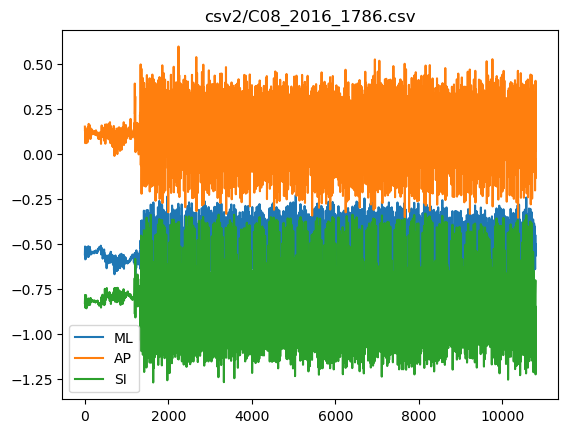

<Figure size 640x480 with 0 Axes>

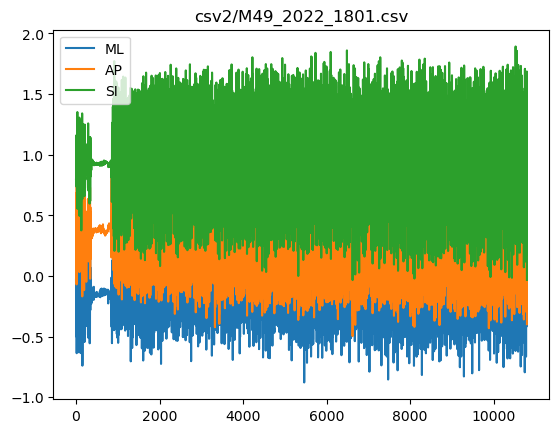

<Figure size 640x480 with 0 Axes>

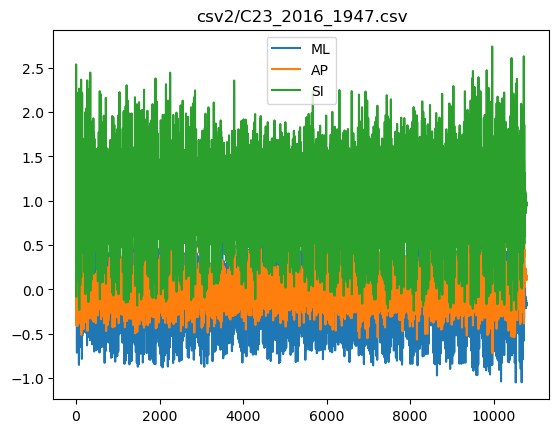

In [53]:
folder = Path('csv2')
csv_files = list(folder.glob("*.csv"))

for f in csv_files[0:3]:
    df = pd.read_csv(f)
    df = df[['ML','AP','SI']]
    plt.figure()
    df.plot()
    plt.title(f)

In [6]:
def compute_sway_jerk(df, sampling_rate=30):
    """
    Compute sway jerkiness (JERK) from acceleration data.
    
    Parameters
    ----------
    df : pd.DataFrame
        Must contain columns ["ML", "AP"].
    sampling_rate : float
        Sampling frequency in Hz (samples per second).
    
    Returns
    -------
    float
        JERK value (m^2/s^5).
    """
    dt = 1.0 / sampling_rate

    # First derivatives (time derivative of acceleration = jerk components)
    dAP_dt = np.gradient(df["AP"].values, dt)
    dML_dt = np.gradient(df["ML"].values, dt)

    # Squared sum inside the integral
    integrand = dAP_dt**2 + dML_dt**2

    # Approximate integral with Riemann sum
    jerk = 0.5 * np.sum(integrand) * dt
    return jerk


def compute_mean_distance(df, use_si=False, to_mm=False):
    """
    Compute mean distance from the center of the COP (ACC) trajectory.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain columns ["ML", "AP"] and optionally ["SI"].
    use_si : bool, default=False
        If True, include SI axis in the distance calculation.
    to_mm : bool, default=False
        If True, convert result from m/s² to mm/s².
    
    Returns
    -------
    float
        Mean distance from center (m/s² or mm/s²).
    """
    axes = ["ML", "AP"] if not use_si else ["ML", "AP", "SI"]
    
    # Center (mean acceleration per axis)
    center = df[axes].mean().values
    
    # Euclidean distance of each point from center
    distances = np.linalg.norm(df[axes].values - center, axis=1)
    
    # Mean distance
    dist_mean = distances.mean()
    
    if to_mm:
        dist_mean *= 1000.0
    
    return dist_mean


def compute_rms_acc(df, use_si=False, to_mm=False):
    """
    Compute RMS of COP (ACC) time series.
    
    Parameters
    ----------
    df : pd.DataFrame
        Must contain columns ["ML", "AP"] and optionally ["SI"].
    use_si : bool, default=False
        If True, include SI axis in the RMS calculation.
    to_mm : bool, default=False
        If True, convert result from m/s² to mm/s².
    
    Returns
    -------
    float
        RMS value (m/s² or mm/s²).
    """
    axes = ["ML", "AP"] if not use_si else ["ML", "AP", "SI"]

    # Squared sum per sample
    squared_sum = np.sum(df[axes].values**2, axis=1)
    
    # Mean and square root
    rms = np.sqrt(squared_sum.mean())
    
    if to_mm:
        rms *= 1000.0
    
    return rms

In [7]:
def compute_path_length(df, use_si=False, to_mm=False):
    """
    Compute sway path (total trajectory length) from COP (ACC) time series.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain columns ["ML", "AP"] and optionally ["SI"].
    use_si : bool, default=False
        If True, include SI axis in path calculation.
    to_mm : bool, default=False
        If True, convert result from m/s² to mm/s².
    
    Returns
    -------
    float
        Path length (m/s² or mm/s²).
    """
    axes = ["ML", "AP"] if not use_si else ["ML", "AP", "SI"]

    # Differences between consecutive samples
    diffs = np.diff(df[axes].values, axis=0)

    # Euclidean step length per time step
    step_lengths = np.linalg.norm(diffs, axis=1)

    # Total path length
    path_length = step_lengths.sum()

    if to_mm:
        path_length *= 1000.0

    return path_length



def compute_range(df, use_si=False, to_mm=False, combine=False):
    """
    Compute range of COP (ACC) displacement.
    
    Parameters
    ----------
    df : pd.DataFrame
        Must contain columns ["ML", "AP"] and optionally ["SI"].
    use_si : bool, default=False
        If True, include SI axis.
    to_mm : bool, default=False
        If True, convert from m/s² to mm/s².
    combine : bool, default=False
        If True, return a single scalar = Euclidean range of bounding box.
        If False, return per-axis ranges in a dict.
    
    Returns
    -------
    float or dict
        Range (m/s² or mm/s²).
    """
    axes = ["ML", "AP"] if not use_si else ["ML", "AP", "SI"]
    
    ranges = {ax: df[ax].max() - df[ax].min() for ax in axes}
    
    if combine:
        # Euclidean diagonal of bounding box
        value = np.sqrt(sum(r**2 for r in ranges.values()))
        return value * 1000.0 if to_mm else value
    
    if to_mm:
        ranges = {ax: val * 1000.0 for ax, val in ranges.items()}
    
    return ranges

def compute_mean_velocity(df, sampling_rate=30, use_si=False, to_mm=False):
    """
    Compute MV = PATH / trial duration.
    """
    # Path length (reuse earlier formula)
    axes = ["ML", "AP"] if not use_si else ["ML", "AP", "SI"]
    diffs = np.diff(df[axes].values, axis=0)
    step_lengths = np.linalg.norm(diffs, axis=1)
    path_length = step_lengths.sum()

    duration = len(df) / sampling_rate
    mv = path_length / duration

    if to_mm:
        mv *= 1000.0
    return mv


In [8]:
def compute_mean_frequency(df, sampling_rate=30, to_mm=False):
    """
    Compute MF = PATH / (2 * π * DIST * trial duration).
    
    Parameters
    ----------
    df : pd.DataFrame
        Must contain ["ML", "AP"] (optionally "SI", but usually excluded).
    sampling_rate : float
        Sampling frequency in Hz.
    to_mm : bool, default=False
        If True, DIST and PATH are converted to mm/s² before MF is calculated.
    
    Returns
    -------
    float
        Mean frequency in Hz.
    """
    # --- PATH ---
    diffs = np.diff(df[["ML", "AP"]].values, axis=0)
    step_lengths = np.linalg.norm(diffs, axis=1)
    path = step_lengths.sum()
    
    # --- DIST ---
    center = df[["ML", "AP"]].mean().values
    distances = np.linalg.norm(df[["ML", "AP"]].values - center, axis=1)
    dist_mean = distances.mean()
    
    # Trial duration
    duration = len(df) / sampling_rate
    
    if to_mm:
        path *= 1000.0
        dist_mean *= 1000.0
    
    mf = path / (2 * np.pi * dist_mean * duration)
    return mf


def compute_sway_area(df, sampling_rate=30, to_mm2=True):
    """
    Compute sway area (95% confidence ellipse area) per unit time.
    
    Parameters
    ----------
    df : pd.DataFrame
        Must contain ["ML", "AP"].
    sampling_rate : int
        Sampling frequency in Hz.
    to_mm2 : bool, default=True
        If True, return area in mm²/s. If False, m²/s.
    
    Returns
    -------
    float
        Sway area per unit time (mm²/s or m²/s).
    """
    ml = df["ML"].values
    ap = df["AP"].values
    
    # Standard deviations
    sigma_ml = np.std(ml, ddof=1)
    sigma_ap = np.std(ap, ddof=1)
    
    # Correlation coefficient
    rho = np.corrcoef(ml, ap)[0, 1]
    
    # Ellipse area (95% CI ellipse, geometric definition)
    area = np.pi * sigma_ml * sigma_ap * np.sqrt(1 - rho**2)
    
    # Normalize by trial duration
    duration = len(df) / sampling_rate
    area_per_time = area / duration
    
    if to_mm2:
        area_per_time *= 1e6  # convert m²/s → mm²/s
    
    return area_per_time


def compute_total_power(df, sampling_rate=30, to_mm2=True):
    """
    Compute total power of COP (ACC) signal in the frequency domain.
    
    Parameters
    ----------
    df : pd.DataFrame
        Must contain ["ML", "AP"].
    sampling_rate : int
        Sampling frequency in Hz.
    to_mm2 : bool, default=True
        If True, result is in mm² (instead of m²).
    
    Returns
    -------
    float
        Total power (mm² or m²), units are m²/s⁴ or mm²/s⁴.
    """
    ml = df["ML"].values
    ap = df["AP"].values
    
    # Welch power spectral density (units: (m/s²)²/Hz)
    f_ml, psd_ml = welch(ml, fs=sampling_rate, nperseg=min(256, len(ml)))
    f_ap, psd_ap = welch(ap, fs=sampling_rate, nperseg=min(256, len(ap)))
    
    # Integrate PSD over frequency to get total power (Parseval’s theorem)
    pwr_ml = np.trapz(psd_ml, f_ml)
    pwr_ap = np.trapz(psd_ap, f_ap)

    
    total_power = pwr_ml + pwr_ap
    
    if to_mm2:
        total_power *= 1e6  # m² → mm²
    
    return total_power

In [9]:
from scipy.signal import welch

def compute_f50(df, sampling_rate=30):
    """
    Compute F50: Median frequency (Hz).
    The frequency below which 50% of total power is present.
    
    Parameters
    ----------
    df : pd.DataFrame
        Must contain ["ML", "AP"].
    sampling_rate : int
        Sampling frequency in Hz.
    
    Returns
    -------
    float
        Median frequency in Hz.
    """
    ml = df["ML"].values
    ap = df["AP"].values
    
    # Welch PSD for both axes
    f_ml, psd_ml = welch(ml, fs=sampling_rate, nperseg=min(256, len(ml)))
    f_ap, psd_ap = welch(ap, fs=sampling_rate, nperseg=min(256, len(ap)))
    
    # Combine power spectra
    psd_total = psd_ml + psd_ap
    
    # Cumulative power
    cumulative_power = np.cumsum(psd_total) * (f_ml[1] - f_ml[0])
    total_power = cumulative_power[-1]
    
    # Find frequency at 50% of total power
    median_freq = np.interp(total_power/2, cumulative_power, f_ml)
    
    return median_freq


def compute_f95(df, sampling_rate=30):
    """
    Compute F95: frequency below which 95% of total power is present.
    
    Parameters
    ----------
    df : pd.DataFrame
        Must contain ["ML", "AP"].
    sampling_rate : int
        Sampling frequency in Hz.
    
    Returns
    -------
    float
        95% power frequency (Hz).
    """
    ml = df["ML"].values
    ap = df["AP"].values
    
    # Welch PSD
    f_ml, psd_ml = welch(ml, fs=sampling_rate, nperseg=min(256, len(ml)))
    f_ap, psd_ap = welch(ap, fs=sampling_rate, nperseg=min(256, len(ap)))
    
    # Combine PSDs
    psd_total = psd_ml + psd_ap
    
    # Cumulative power
    cumulative_power = np.cumsum(psd_total) * (f_ml[1] - f_ml[0])
    total_power = cumulative_power[-1]
    
    # Find frequency where cumulative power reaches 95%
    f95 = np.interp(0.95 * total_power, cumulative_power, f_ml)
    
    return f95


def compute_centroidal_frequency(df, sampling_rate=30):
    """
    Compute CF: Centroidal frequency (Hz).
    Power-weighted average frequency of ML+AP spectra.
    
    Parameters
    ----------
    df : pd.DataFrame
        Must contain ["ML", "AP"].
    sampling_rate : int
        Sampling frequency in Hz.
    
    Returns
    -------
    float
        Centroidal frequency (Hz).
    """
    ml = df["ML"].values
    ap = df["AP"].values
    
    # Welch PSD for ML and AP
    f_ml, psd_ml = welch(ml, fs=sampling_rate, nperseg=min(256, len(ml)))
    f_ap, psd_ap = welch(ap, fs=sampling_rate, nperseg=min(256, len(ap)))
    
    # Combine PSDs
    psd_total = psd_ml + psd_ap
    
    # Weighted mean frequency
    numerator = np.sum(f_ml * psd_total)
    denominator = np.sum(psd_total)
    
    if denominator == 0:
        return 0.0
    
    cf = numerator / denominator
    return cf


def compute_frequency_dispersion(df, sampling_rate=30):
    """
    Compute FD: Frequency dispersion (dimensionless).
    
    Parameters
    ----------
    df : pd.DataFrame
        Must contain ["ML", "AP"].
    sampling_rate : int
        Sampling frequency in Hz.
    
    Returns
    -------
    float
        Frequency dispersion (−).
    """
    ml = df["ML"].values
    ap = df["AP"].values
    
    # Welch PSD for ML and AP
    f_ml, psd_ml = welch(ml, fs=sampling_rate, nperseg=min(256, len(ml)))
    f_ap, psd_ap = welch(ap, fs=sampling_rate, nperseg=min(256, len(ap)))
    
    # Combine spectra
    f = f_ml  # frequencies are identical
    psd_total = psd_ml + psd_ap
    
    # Centroidal frequency (CF)
    numerator = np.sum(f * psd_total)
    denominator = np.sum(psd_total)
    if denominator == 0:
        return 0.0
    cf = numerator / denominator
    
    # Spectral variance around CF
    variance = np.sum(((f - cf) ** 2) * psd_total) / denominator
    
    # Frequency dispersion (std / mean)
    fd = np.sqrt(variance) / cf if cf > 0 else 0.0
    
    return fd

In [10]:
import EntropyHub as EH
import nolds

def approximate_entropy(U):
    """
    Compute Approximate Entropy (ApEn) of a time series.
    
    Parameters
    ----------
    U : array-like
        Time series (1D).
    m : int
        Embedding dimension (default=2).
    r : float or None
        Tolerance (if None, set to 0.2 * std).
    
    Returns
    -------
    float
        Approximate entropy (ApEn).
    """
    U = np.array(U)
    return EH.ApEn(U)


def lyapunov_exponent(U):
    """
    Safe wrapper around nolds.lyap_r that adapts min_tsep
    and suppresses runtime warnings for low-frequency signals.

    Parameters
    ----------
    U : array-like
        Time series (1D).
    Returns
    -------
    float
        Estimated Largest Lyapunov Exponent (LyExp).
    """
    U = np.asarray(U)
    return nolds.lyap_r(U)

def compute_apen_lyexp(df, m=2, r=None, emb_dim=2, tau=1, max_t=20):
    """
    Compute Approximate Entropy and Lyapunov Exponent
    for magnitude of AP + ML acceleration.
    
    Parameters
    ----------
    df : pd.DataFrame
        Must contain ["AP", "ML"].
    
    Returns
    -------
    apen, lyexp
    """
    
    mag = np.sqrt(df["AP"].values**2 + df["ML"].values**2)
    
    apen = approximate_entropy(mag)
    # lyexp = lyapunov_exponent(mag)
    
    return apen


In [11]:
def stat_list(data):
    """
    Compute percentiles and standard deviation of a list/array.

    Parameters
    ----------
    data : list or array-like

    Returns
    -------
    dict with statistics
    """
    arr = np.asarray(data)

    stats = {
        "5th_percentile": np.percentile(arr, 5),
        "25th_percentile": np.percentile(arr, 25),
        "median": np.percentile(arr, 50),
        "75th_percentile": np.percentile(arr, 75),
        "95th_percentile": np.percentile(arr, 95),
        "std_dev": np.std(arr, ddof=1)   # population std (use ddof=1 for sample std)
    }
    return stats

In [54]:
jerks, dists, rmses, paths, ranges, mvs, mfs = [], [], [], [], [], [], [] 
areas, pwrs, f50s, f95s, cfs, fds = [], [], [], [], [], []
apens, lyexps = [], []

# window_size = 900
# step = 5 

window_size = 1800
step = 900

folder = Path('csv2')
csv_files = list(folder.glob("*.csv"))

all_rows = []
for f in tqdm(csv_files):
    df = pd.read_csv(f)
    df = df[['ML','AP','SI']]

    stem = f.stem 
    parts = stem.split("_")   
    pid, year, sixmwd = parts 
    year, sixmwd = int(year), int(sixmwd)

    for start in tqdm(range(0, len(df) - window_size + 1, step)):
        chunk = df.iloc[start:start+window_size]
        
        # compute features per chunk
        jerks.append(compute_sway_jerk(chunk))
        dists.append(compute_mean_distance(chunk))
        rmses.append(compute_rms_acc(chunk))
        paths.append(compute_path_length(chunk))
        ranges.append(compute_range(chunk, combine=True))
        mvs.append(compute_mean_velocity(chunk))
        mfs.append(compute_mean_frequency(chunk))
        areas.append(compute_sway_area(chunk))
        pwrs.append(compute_total_power(chunk))
        f50s.append(compute_f50(chunk))
        f95s.append(compute_f95(chunk))
        cfs.append(compute_centroidal_frequency(chunk))
        fds.append(compute_frequency_dispersion(chunk))
        # apen = compute_apen_lyexp(chunk)
        # apens.append(apen) 
        # lyexps.append(lyexp)
    
    jerk_stats   = stat_list(jerks)
    dist_stats   = stat_list(dists)
    rms_stats    = stat_list(rmses)
    path_stats   = stat_list(paths)
    range_stats  = stat_list(ranges)
    mv_stats     = stat_list(mvs)
    mf_stats     = stat_list(mfs)
    
    area_stats  = stat_list(areas)
    pwr_stats   = stat_list(pwrs)
    f50_stats   = stat_list(f50s)
    f95_stats   = stat_list(f95s)
    cf_stats    = stat_list(cfs)
    fd_stats    = stat_list(fds)
    
    # apen_stats = stat_list(apens)
    # lyexps_stats = stat_list(lyexps)
    
    # Combine into a single row
    row = {

        "pid" : pid,
        "year": year,
        
        "jerk_5th":   jerk_stats["5th_percentile"],
        "jerk_25th":  jerk_stats["25th_percentile"],
        "jerk_median":jerk_stats["median"],
        "jerk_75th":  jerk_stats["75th_percentile"],
        "jerk_95th":  jerk_stats["95th_percentile"],
        "jerk_std":   jerk_stats["std_dev"],
    
        "dist_5th":   dist_stats["5th_percentile"],
        "dist_25th":  dist_stats["25th_percentile"],
        "dist_median":dist_stats["median"],
        "dist_75th":  dist_stats["75th_percentile"],
        "dist_95th":  dist_stats["95th_percentile"],
        "dist_std":   dist_stats["std_dev"],
    
        "rms_5th":    rms_stats["5th_percentile"],
        "rms_25th":   rms_stats["25th_percentile"],
        "rms_median": rms_stats["median"],
        "rms_75th":   rms_stats["75th_percentile"],
        "rms_95th":   rms_stats["95th_percentile"],
        "rms_std":    rms_stats["std_dev"],
    
        "path_5th":   path_stats["5th_percentile"],
        "path_25th":  path_stats["25th_percentile"],
        "path_median":path_stats["median"],
        "path_75th":  path_stats["75th_percentile"],
        "path_95th":  path_stats["95th_percentile"],
        "path_std":   path_stats["std_dev"],
    
        "range_5th":  range_stats["5th_percentile"],
        "range_25th": range_stats["25th_percentile"],
        "range_median":range_stats["median"],
        "range_75th": range_stats["75th_percentile"],
        "range_95th": range_stats["95th_percentile"],
        "range_std":  range_stats["std_dev"],
    
        "mv_5th":     mv_stats["5th_percentile"],
        "mv_25th":    mv_stats["25th_percentile"],
        "mv_median":  mv_stats["median"],
        "mv_75th":    mv_stats["75th_percentile"],
        "mv_95th":    mv_stats["95th_percentile"],
        "mv_std":     mv_stats["std_dev"],
    
        "mf_5th":     mf_stats["5th_percentile"],
        "mf_25th":    mf_stats["25th_percentile"],
        "mf_median":  mf_stats["median"],
        "mf_75th":    mf_stats["75th_percentile"],
        "mf_95th":    mf_stats["95th_percentile"],
        "mf_std":     mf_stats["std_dev"],
    
        "area_5th":    area_stats["5th_percentile"],
        "area_25th":   area_stats["25th_percentile"],
        "area_median": area_stats["median"],
        "area_75th":   area_stats["75th_percentile"],
        "area_95th":   area_stats["95th_percentile"],
        "area_std":    area_stats["std_dev"],
    
        "pwr_5th":     pwr_stats["5th_percentile"],
        "pwr_25th":    pwr_stats["25th_percentile"],
        "pwr_median":  pwr_stats["median"],
        "pwr_75th":    pwr_stats["75th_percentile"],
        "pwr_95th":    pwr_stats["95th_percentile"],
        "pwr_std":     pwr_stats["std_dev"],
    
        "f50_5th":     f50_stats["5th_percentile"],
        "f50_25th":    f50_stats["25th_percentile"],
        "f50_median":  f50_stats["median"],
        "f50_75th":    f50_stats["75th_percentile"],
        "f50_95th":    f50_stats["95th_percentile"],
        "f50_std":     f50_stats["std_dev"],
    
        "f95_5th":     f95_stats["5th_percentile"],
        "f95_25th":    f95_stats["25th_percentile"],
        "f95_median":  f95_stats["median"],
        "f95_75th":    f95_stats["75th_percentile"],
        "f95_95th":    f95_stats["95th_percentile"],
        "f95_std":     f95_stats["std_dev"],
    
        "cf_5th":      cf_stats["5th_percentile"],
        "cf_25th":     cf_stats["25th_percentile"],
        "cf_median":   cf_stats["median"],
        "cf_75th":     cf_stats["75th_percentile"],
        "cf_95th":     cf_stats["95th_percentile"],
        "cf_std":      cf_stats["std_dev"],
    
        "fd_5th":      fd_stats["5th_percentile"],
        "fd_25th":     fd_stats["25th_percentile"],
        "fd_median":   fd_stats["median"],
        "fd_75th":     fd_stats["75th_percentile"],
        "fd_95th":     fd_stats["95th_percentile"],
        "fd_std":      fd_stats["std_dev"],
    
        "fd_5th":      fd_stats["5th_percentile"],
        "fd_25th":     fd_stats["25th_percentile"],
        "fd_median":   fd_stats["median"],
        "fd_75th":     fd_stats["75th_percentile"],
        "fd_95th":     fd_stats["95th_percentile"],
        "fd_std":      fd_stats["std_dev"],
    
        # "apen_5th":      apen_stats["5th_percentile"],
        # "apen_25th":     apen_stats["25th_percentile"],
        # "apen_median":   apen_stats["median"],
        # "apen_75th":     apen_stats["75th_percentile"],
        # "apen_95th":     apen_stats["95th_percentile"],
        # "apen_std":      apen_stats["std_dev"],
    
        # "lyexp_5th":      lyexps_stats["5th_percentile"],
        # "lyexp_25th":     lyexps_stats["25th_percentile"],
        # "lyexp_median":   lyexps_stats["median"],
        # "lyexp_75th":     lyexps_stats["75th_percentile"],
        # "lyexp_95th":     lyexps_stats["95th_percentile"],
        # "lyexp_std":      lyexps_stats["std_dev"],

        "label" : sixmwd
    }
    
    all_rows.append(row)

df_features = pd.DataFrame(all_rows)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 141.29it/s]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 142.99it/s]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 141.32it/s]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 141.43it/s]

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

In [55]:
df_features

,pid,year,jerk_5th,jerk_25th,jerk_median,jerk_75th,jerk_95th,jerk_std,dist_5th,dist_25th,...,cf_75th,cf_95th,cf_std,fd_5th,fd_25th,fd_median,fd_75th,fd_95th,fd_std,label
0,C08,2016,134.404342,246.231940,251.907181,260.844115,263.603809,56.756119,0.115121,0.179153,...,2.261318,2.291558,0.036490,0.455813,0.458118,0.459482,0.464324,0.503616,0.021579,1786
1,M49,2022,199.399665,252.051491,497.109630,1289.438432,1476.838169,551.117341,0.153424,0.181579,...,2.965787,3.001169,0.370714,0.398944,0.425400,0.454061,0.459321,0.476936,0.030597,1801
2,C23,2016,223.914720,261.633861,1172.993833,1361.702693,1621.435446,565.007859,0.167759,0.185177,...,3.382959,3.514566,0.508177,0.378948,0.391815,0.425353,0.457561,0.471051,0.037372,1947
3,C51,2017,243.090278,612.957115,1219.694545,1374.673401,1647.892564,514.683014,0.178475,0.208430,...,3.088034,3.456571,0.456806,0.341800,0.373889,0.397915,0.453188,0.466037,0.046790,2079
4,M26,2025,248.027176,805.188349,1112.936743,1345.676312,1564.118698,467.616703,0.179540,0.283070,...,2.984953,3.448598,0.456688,0.344266,0.381250,0.404008,0.440047,0.469981,0.045964,2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159,M50,2023,197.060469,546.932155,909.292585,1377.226454,2553.297364,725.828342,0.165239,0.242433,...,2.744085,3.030828,0.414072,0.317114,0.364292,0.405801,0.456372,0.609520,0.170151,2012
160,M07,2016,198.958687,547.878567,912.518454,1374.037752,2540.040182,723.758825,0.164927,0.242704,...,2.747843,3.040466,0.414815,0.317219,0.363785,0.405104,0.456282,0.608839,0.169830,2084
161,M02,2022,200.747795,550.018687,917.631885,1373.663665,2526.430897,721.760989,0.165322,0.243017,...,2.746453,3.038565,0.413737,0.317317,0.363906,0.404565,0.456115,0.608516,0.169349,2269
162,C09,2016,200.763688,550.618554,912.518454,1364.396534,2521.569874,720.561137,0.164996,0.242461,...,2.744584,3.037779,0.412927,0.317335,0.364042,0.405104,0.456498,0.607787,0.169113,2207


In [56]:
df_features.to_csv('msfeature_table3.csv', index=False)